In [1]:
import pyabf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [2]:
laser_ma = {8: 500, 9: 700, 10: 900, 11: 1000, 12: 1100, 13: 1200, 14: 1400}
archivos = [8, 9, 10, 11, 12, 13, 14]
fases = ["control", "laser", "rec"]
colores  = {"control": "#1a6fad", "laser": "#c0392b", "rec": "#2e7d32"}

ruta_base = r"C:\Users\Usuario\Documents\TFG\Experimento ABRIL 2026\27042026 patch"
ruta_analisis = r"C:\Users\Usuario\Documents\TFG\Experimento ABRIL 2026\ANÁLISIS"

FASE_DURACION = 150

archivos_info = {
    8:  {"control": (0, 163.1), "laser": (163.1, 314.8), "rec": (314.8, 480.0)},
    9:  {"control": (0, 154.3), "laser": (154.3, 310.3), "rec": (310.3, 480.0)},
    10: {"control": (0, 155.6), "laser": (155.6, 311.4), "rec": (311.4, 480.0)},
    11: {"control": (0, 152.1), "laser": (152.1, 304.9), "rec": (304.9, 480.0)},
    12: {"control": (0, 156.4), "laser": (156.4, 314.4), "rec": (314.4, 480.0)},
    13: {"control": (0, 153.7), "laser": (153.7, 314.3), "rec": (314.3, 480.0)},
    14: {"control": (0, 152.9), "laser": (152.9, 307.8), "rec": (307.8, 480.0)},
}

## Cálculo de la amplitud del AP

La amplitud se define como la diferencia entre el voltaje en el pico y el potencial de reposo local.
El reposo local se estima como la media del voltaje en la ventana [-8ms, -5ms] antes del pico,
la misma ventana que usamos para las pendientes.

In [4]:
datos_amp = {num: {fase: [] for fase in fases} for num in archivos}

for num in archivos:
    abf = pyabf.ABF(rf"{ruta_base}\264270{num:02d}.abf")
    abf.setSweep(0, channel=0)
    tiempo = abf.sweepX
    vm = abf.sweepY
    fs = abf.dataRate

    w_reposo_fin = int(5 * fs / 1000)
    w_reposo_dur = int(3 * fs / 1000)

    for fase in fases:
        t0 = archivos_info[num][fase][0]
        mask = (tiempo >= t0) & (tiempo <= t0 + FASE_DURACION)
        vm_fase = vm[mask]

        picos, _ = find_peaks(vm_fase, height=0, distance=int(0.05 * fs))
# sino da error prq el archivo 14 tiene 0 APs en fase láser
        for p in picos:
            if p - w_reposo_fin - w_reposo_dur < 0:
                continue
            reposo_local = np.mean(vm_fase[p - w_reposo_fin - w_reposo_dur : p - w_reposo_fin])
            datos_amp[num][fase].append(vm_fase[p] - reposo_local)

filas = []
for num in archivos:
    for fase in fases:
        vals = datos_amp[num][fase]
        filas.append({
            "archivo": num,
            "intensidad (mA)": laser_ma[num],
            "fase": fase,
            "media (mV)": round(np.mean(vals), 2) if vals else np.nan, # 0 APs en 14
            "std (mV)": round(np.std(vals), 2) if vals else np.nan,
            "mediana (mV)": round(np.median(vals),2) if vals else np.nan,
            "n APs":len(vals),
        })

df_amp = pd.DataFrame(filas)
df_amp

,archivo,intensidad (mA),fase,media (mV),std (mV),mediana (mV),n APs
0,8,500,control,72.430000,5.77,70.769997,143
1,8,500,laser,67.820000,8.10,63.669998,160
2,8,500,rec,86.150002,6.70,82.139999,99
3,9,700,control,90.790001,3.07,91.489998,48
4,9,700,laser,74.870003,1.10,75.000000,16
5,9,700,rec,82.320000,5.50,84.839996,79
6,10,900,control,78.529999,5.79,77.860001,89
7,10,900,laser,65.510002,1.56,65.330002,62
8,10,900,rec,73.779999,5.22,72.230003,91
9,11,1000,control,72.769997,5.22,69.800003,101


## Boxplot de amplitud por intensidad del láser

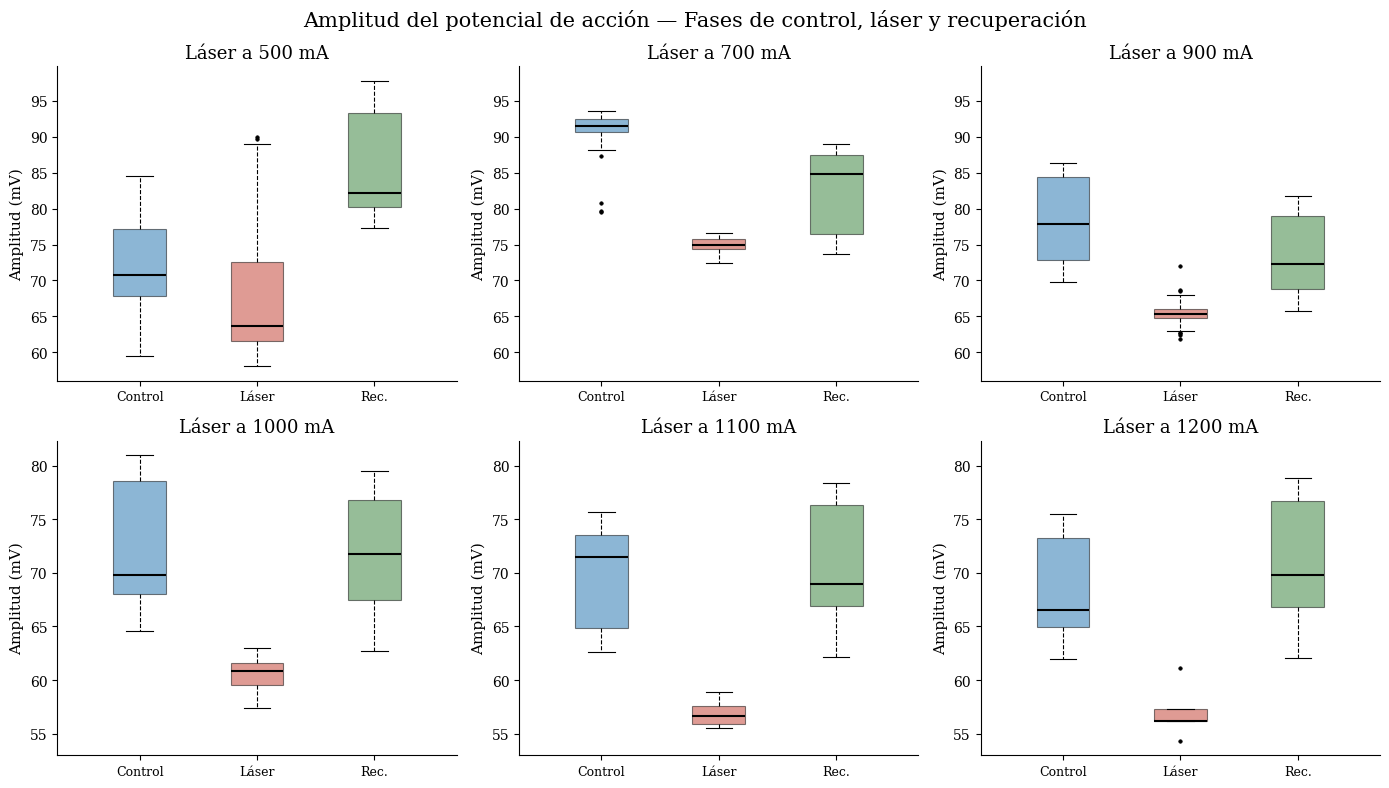

In [5]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

archivos_plot = [8, 9, 10, 11, 12, 13]

# Límites Y por fila
ymin_fila = {0: np.inf, 1: np.inf}
ymax_fila = {0: -np.inf, 1: -np.inf}
for idx, n in enumerate(archivos_plot):
    fila = idx // 3
    for fase in fases:
        vals = datos_amp[n][fase]
        ymin_fila[fila] = min(ymin_fila[fila], np.min(vals))
        ymax_fila[fila] = max(ymax_fila[fila], np.max(vals))
for fila in [0, 1]:
    rng = ymax_fila[fila] - ymin_fila[fila]
    ymin_fila[fila] -= rng * 0.05
    ymax_fila[fila] += rng * 0.05

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for idx, n in enumerate(archivos_plot):
    fila = idx // 3
    ax = axes[fila][idx % 3]
    datos = [datos_amp[n][fase] for fase in fases]

    bp = ax.boxplot(datos, positions=[1, 2, 3], widths=0.45,
                    patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=1.5),
                    whiskerprops=dict(linewidth=0.8, color='black', linestyle='--'),
                    capprops=dict(linewidth=0.8, color='black'),
                    boxprops=dict(linewidth=0.8),
                    flierprops=dict(marker='o', markersize=2.5, linestyle='none',
                                    markeredgewidth=0.5, markeredgecolor='black'))

    for patch, fase in zip(bp['boxes'], fases):
        patch.set_facecolor(colores[fase])
        patch.set_alpha(0.5)
        patch.set_edgecolor('black')

    for flier in bp['fliers']:
        flier.set_markerfacecolor('black')

    ax.set_ylim(ymin_fila[fila], ymax_fila[fila])
    ax.set_title(f"Láser a {laser_ma[n]} mA", fontsize=13)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(['Control', 'Láser', 'Rec.'], fontsize=9)
    ax.set_xlim(0.3, 3.7)
    ax.set_ylabel("Amplitud (mV)", fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle("Amplitud del potencial de acción — Fases de control, láser y recuperación", fontsize=15)
plt.tight_layout()
plt.show()